# 00 Data Exploration — M5 Retail Demand

This notebook is the first exploratory pass for the retail replenishment and allocation project. The goal is to understand the M5 Walmart dataset before moving into forecasting, inventory logic, or allocation rules.

Main objectives:
1. Understand how `Y_df`, `X_df`, and `S_df` fit together.
2. Audit the sales history and retail hierarchy.
3. Build clear category-level daily views for trend, seasonality, and low-sales diagnostics.
4. Keep the analysis portfolio-friendly and easy to extend later.


## 1. Setup

This notebook keeps the setup block intentionally thin. Reusable plotting, path resolution, and calendar helpers live in `helpers/eda.py` so they can be reused in later feature engineering notebooks.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from datasetsforecast.m5 import M5

from helpers import *

ModuleNotFoundError: No module named 'helpers'

## 2. Load M5 data

`datasetsforecast` returns three related tables:

- `Y_df`: the target sales history
- `X_df`: time-varying features such as sell price, events, and SNAP indicators
- `S_df`: static item/store/category metadata

We will inspect them separately first, then join them into one analytical table called `m5`.


In [ ]:
Y_df, X_df, S_df = M5.load(directory="data", cache=True)

print("Y_df:", Y_df.shape)
print("X_df:", X_df.shape)
print("S_df:", S_df.shape)


Y_df: (47649940, 3)
X_df: (47649940, 10)
S_df: (30490, 6)


### Quick look at the three source tables


In [ ]:
Y_df.head()


,unique_id,ds,y
0,FOODS_1_001_CA_1,2011-01-29,3.0
1,FOODS_1_001_CA_1,2011-01-30,0.0
2,FOODS_1_001_CA_1,2011-01-31,0.0
3,FOODS_1_001_CA_1,2011-02-01,1.0
4,FOODS_1_001_CA_1,2011-02-02,4.0


In [ ]:
X_df.head()


,unique_id,ds,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_001_CA_1,2011-01-29,nan,nan,nan,nan,0,0,0,2.0
1,FOODS_1_001_CA_1,2011-01-30,nan,nan,nan,nan,0,0,0,2.0
2,FOODS_1_001_CA_1,2011-01-31,nan,nan,nan,nan,0,0,0,2.0
3,FOODS_1_001_CA_1,2011-02-01,nan,nan,nan,nan,1,1,0,2.0
4,FOODS_1_001_CA_1,2011-02-02,nan,nan,nan,nan,1,0,1,2.0


In [ ]:
S_df.head()


,unique_id,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1969,FOODS_1_001_CA_2,FOODS_1_001,FOODS_1,FOODS,CA_2,CA
3938,FOODS_1_001_CA_3,FOODS_1_001,FOODS_1,FOODS,CA_3,CA
5907,FOODS_1_001_CA_4,FOODS_1_001,FOODS_1,FOODS,CA_4,CA
7875,FOODS_1_001_TX_1,FOODS_1_001,FOODS_1,FOODS,TX_1,TX


## 3. Initial schema and data quality audit

Before aggregating anything, confirm the basic structure of each table and check for obvious target issues such as duplicates, missing values, or negative sales.


In [ ]:
print("Date range:", Y_df["ds"].min(), "to", Y_df["ds"].max())
print("Number of unique series:", Y_df["unique_id"].nunique())
print("Rows:", len(Y_df))
print("Duplicate unique_id-date rows:", Y_df.duplicated(subset=["unique_id", "ds"]).sum())
print("Negative sales rows:", (Y_df["y"] < 0).sum())
print("Missing target values:", Y_df["y"].isna().sum())


Date range: 2011-01-29 00:00:00 to 2016-06-19 00:00:00
Number of unique series: 30490
Rows: 47649940
Duplicate unique_id-date rows: 0
Negative sales rows: 0
Missing target values: 0


## 4. Create the main joined table

`m5` is the main SKU-store-day table used through the rest of the notebook. It combines:

- target sales from `Y_df`
- time-varying attributes from `X_df`
- static hierarchy attributes from `S_df`


In [ ]:
# Join sales, time-varying features, and static hierarchy into one analytical table.
m5 = (
    Y_df
    .merge(X_df, on=["unique_id", "ds"], how="left")
    .merge(S_df, on="unique_id", how="left")
)

print("m5 shape:", m5.shape)
m5.head()


m5 shape: (47649940, 16)


,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,2011-01-29,3.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1,FOODS_1_001_CA_1,2011-01-30,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
2,FOODS_1_001_CA_1,2011-01-31,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
3,FOODS_1_001_CA_1,2011-02-01,1.0,nan,nan,nan,nan,1,1,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
4,FOODS_1_001_CA_1,2011-02-02,4.0,nan,nan,nan,nan,1,0,1,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA


In [ ]:
missing_summary = (
    m5.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .reset_index()
    .rename(columns={"index": "column"})
)

missing_summary.head(25)


,column,missing_rate
0,unique_id,0.0
1,ds,0.0
2,y,0.0
3,event_name_1,0.0
4,event_type_1,0.0
5,event_name_2,0.0
6,event_type_2,0.0
7,snap_CA,0.0
8,snap_TX,0.0
9,snap_WI,0.0


In [ ]:
series_lengths = (
    m5.groupby("unique_id", observed=True)["ds"]
    .agg(start_date="min", end_date="max", observations="count")
    .reset_index()
)

series_lengths.describe(include="all")


,unique_id,start_date,end_date,observations
count,30490,30490,30490,30490.000000
unique,30490,NaN,NaN,NaN
top,FOODS_1_001_CA_1,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,2012-03-10 04:40:03.935716608,2016-06-19 00:00:00.000000256,1562.805510
min,NaN,2011-01-29 00:00:00,2016-06-19 00:00:00,124.000000
25%,NaN,2011-01-30 00:00:00,2016-06-19 00:00:00,1203.000000
50%,NaN,2011-07-07 00:00:00,2016-06-19 00:00:00,1810.000000
75%,NaN,2013-03-05 00:00:00,2016-06-19 00:00:00,1968.000000
max,NaN,2016-02-17 00:00:00,2016-06-19 00:00:00,1969.000000


## 5. Hierarchy exploration

The retail structure matters because this project will eventually move between SKU-store decisions and higher-level category signals. This section maps the hierarchy first.


In [ ]:
hierarchy_cols = ["state_id", "store_id", "cat_id", "dept_id", "item_id"]

S_df[hierarchy_cols].nunique()


state_id       3
store_id      10
cat_id         3
dept_id        7
item_id     3049
dtype: int64

In [ ]:
unique_values = {
    col: sorted(S_df[col].dropna().unique().tolist())
    for col in hierarchy_cols
}

# item_id is long, so preview only the first 20 values.
for col, values in unique_values.items():
    print(f"\n{col}: {len(values)} unique")
    print(values[:10])



state_id: 3 unique
['CA', 'TX', 'WI']

store_id: 10 unique
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']

cat_id: 3 unique
['FOODS', 'HOBBIES', 'HOUSEHOLD']

dept_id: 7 unique
['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']

item_id: 3049 unique
['FOODS_1_001', 'FOODS_1_002', 'FOODS_1_003', 'FOODS_1_004', 'FOODS_1_005', 'FOODS_1_006', 'FOODS_1_008', 'FOODS_1_009', 'FOODS_1_010', 'FOODS_1_011']


In [ ]:
store_category_structure = (
    S_df
    .groupby(["state_id", "store_id", "cat_id"], observed=True)
    .agg(
        item_count=("item_id", "nunique"),
        series_count=("unique_id", "nunique"),
    )
    .reset_index()
    .sort_values(["state_id", "store_id", "cat_id"])
)

store_category_structure


,state_id,store_id,cat_id,item_count,series_count
0,CA,CA_1,HOBBIES,565,565
1,CA,CA_1,HOUSEHOLD,1047,1047
2,CA,CA_1,FOODS,1437,1437
3,CA,CA_2,HOBBIES,565,565
4,CA,CA_2,HOUSEHOLD,1047,1047
5,CA,CA_2,FOODS,1437,1437
6,CA,CA_3,HOBBIES,565,565
7,CA,CA_3,HOUSEHOLD,1047,1047
8,CA,CA_3,FOODS,1437,1437
9,CA,CA_4,HOBBIES,565,565


In [ ]:
hierarchy_summary = (
    S_df
    .groupby(["state_id", "store_id", "cat_id", "dept_id"], observed=True)
    .agg(series_count=("unique_id", "nunique"))
    .reset_index()
    .sort_values(["state_id", "store_id", "cat_id", "dept_id"])
)

hierarchy_summary.head(25)


,state_id,store_id,cat_id,dept_id,series_count
0,CA,CA_1,HOBBIES,HOBBIES_1,416
1,CA,CA_1,HOBBIES,HOBBIES_2,149
2,CA,CA_1,HOUSEHOLD,HOUSEHOLD_1,532
3,CA,CA_1,HOUSEHOLD,HOUSEHOLD_2,515
4,CA,CA_1,FOODS,FOODS_1,216
5,CA,CA_1,FOODS,FOODS_2,398
6,CA,CA_1,FOODS,FOODS_3,823
7,CA,CA_2,HOBBIES,HOBBIES_1,416
8,CA,CA_2,HOBBIES,HOBBIES_2,149
9,CA,CA_2,HOUSEHOLD,HOUSEHOLD_1,532


## 6. Build the core category-level views

We keep three related category-level tables throughout the notebook:

- `category_daily_raw`: the source-of-truth category-day sales table with all dates retained
- `category_daily_event_enriched`: the same sales totals enriched with event and calendar flags for diagnostics
- `category_daily_normalized`: a diagnostic-only view that excludes December 25 so one extreme holiday does not dominate certain charts

Important: December 25 is **not** deleted from the raw data. It stays in the raw and event-aware views. It is only excluded from the normalized diagnostic view.


In [ ]:
# Raw category view: this keeps every observed category-day exactly as loaded.
category_daily_raw = (
    m5
    .groupby(["ds", "cat_id"], observed=True)
    .agg(y=("y", "sum"))
    .reset_index()
    .sort_values(["cat_id", "ds"])
)

# Event columns are date-level, so deduplicate them before joining onto category totals.
calendar_daily = (
    X_df[["ds", "event_name_1", "event_type_1", "event_name_2", "event_type_2"]]
    .drop_duplicates()
    .sort_values("ds")
)

assert calendar_daily["ds"].is_unique, "Expected one calendar row per date."

# Event-adjusted means calendar-aware for diagnostics; sales values are not mathematically altered here.
category_daily_event_enriched = add_calendar_flags(
    category_daily_raw.merge(calendar_daily, on="ds", how="left")
).sort_values(["cat_id", "ds"])

# Normalized view is diagnostic only: exclude Dec 25 to inspect typical demand without one extreme holiday dominating.
category_daily_normalized = category_daily_event_enriched.loc[
    ~category_daily_event_enriched["is_christmas"]
].copy()

view_summary = pd.DataFrame(
    [
         {
             "view_name": "category_daily_raw",
             "rows": len(category_daily_raw),
            "includes_dec_25": (
                category_daily_raw["ds"].dt.month.eq(12)
                & category_daily_raw["ds"].dt.day.eq(25)
            ).any(),
             "purpose": "Source-of-truth category sales history",
         },
        {
            "view_name": "category_daily_event_enriched",
            "rows": len(category_daily_event_enriched),
            "includes_dec_25": category_daily_event_enriched["is_christmas"].any(),
            "purpose": "Same sales totals plus event and calendar flags",
        },
        {
            "view_name": "category_daily_normalized",
            "rows": len(category_daily_normalized),
            "includes_dec_25": category_daily_normalized["is_christmas"].any(),
            "purpose": "Diagnostic view excluding Dec 25 only",
        },
    ]
)

view_summary


,view_name,rows,includes_dec_25,purpose
0,category_daily_raw,5907,True,Source-of-truth category sales history
1,category_daily_event_enriched,5907,True,Same sales totals plus event and calendar flags
2,category_daily_normalized,5892,False,Diagnostic view excluding Dec 25 only


In [ ]:
print(category_daily_raw.shape)
print(category_daily_event_enriched.shape)
print(category_daily_normalized.shape)

(5907, 3)
(5907, 17)
(5892, 17)


In [ ]:
# These lower-level aggregates will be useful later for supply-chain diagnostics.
store_category_daily = (
    m5
    .groupby(["ds", "state_id", "store_id", "cat_id"], observed=True)
    .agg(y=("y", "sum"))
    .reset_index()
    .sort_values(["state_id", "store_id", "cat_id", "ds"])
)

state_category_daily = (
    m5
    .groupby(["ds", "state_id", "cat_id"], observed=True)
    .agg(y=("y", "sum"))
    .reset_index()
    .sort_values(["state_id", "cat_id", "ds"])
)

store_category_daily.head()


,ds,state_id,store_id,cat_id,y
0,2011-01-29,CA,CA_1,HOBBIES,556.0
30,2011-01-30,CA,CA_1,HOBBIES,498.0
60,2011-01-31,CA,CA_1,HOBBIES,415.0
90,2011-02-01,CA,CA_1,HOBBIES,392.0
120,2011-02-02,CA,CA_1,HOBBIES,268.0


## 7. Total and category-level sales trends

Start with the most readable business view: total daily sales and category-level daily sales. This gives a first sense of overall scale, trend smoothness, and whether one category dominates the signal.


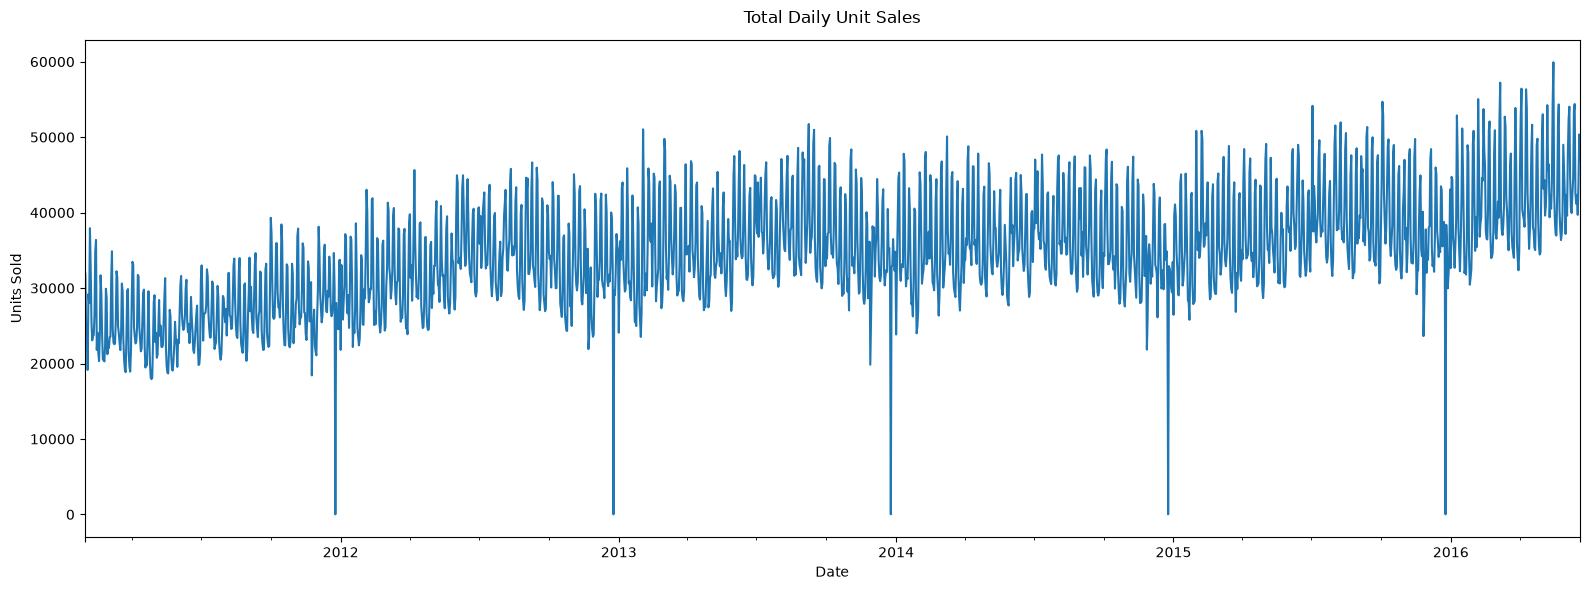

In [ ]:
daily_sales = (
    category_daily_event_enriched
    .groupby("ds", observed=True)
    .agg(y=("y", "sum"))
    .reset_index()
)

ax = daily_sales.plot(x="ds", y="y", figsize=(16, 6), legend=False, color="tab:blue")
finish_axis(ax, title="Total Daily Unit Sales", xlabel="Date", ylabel="Units Sold")
plt.show()


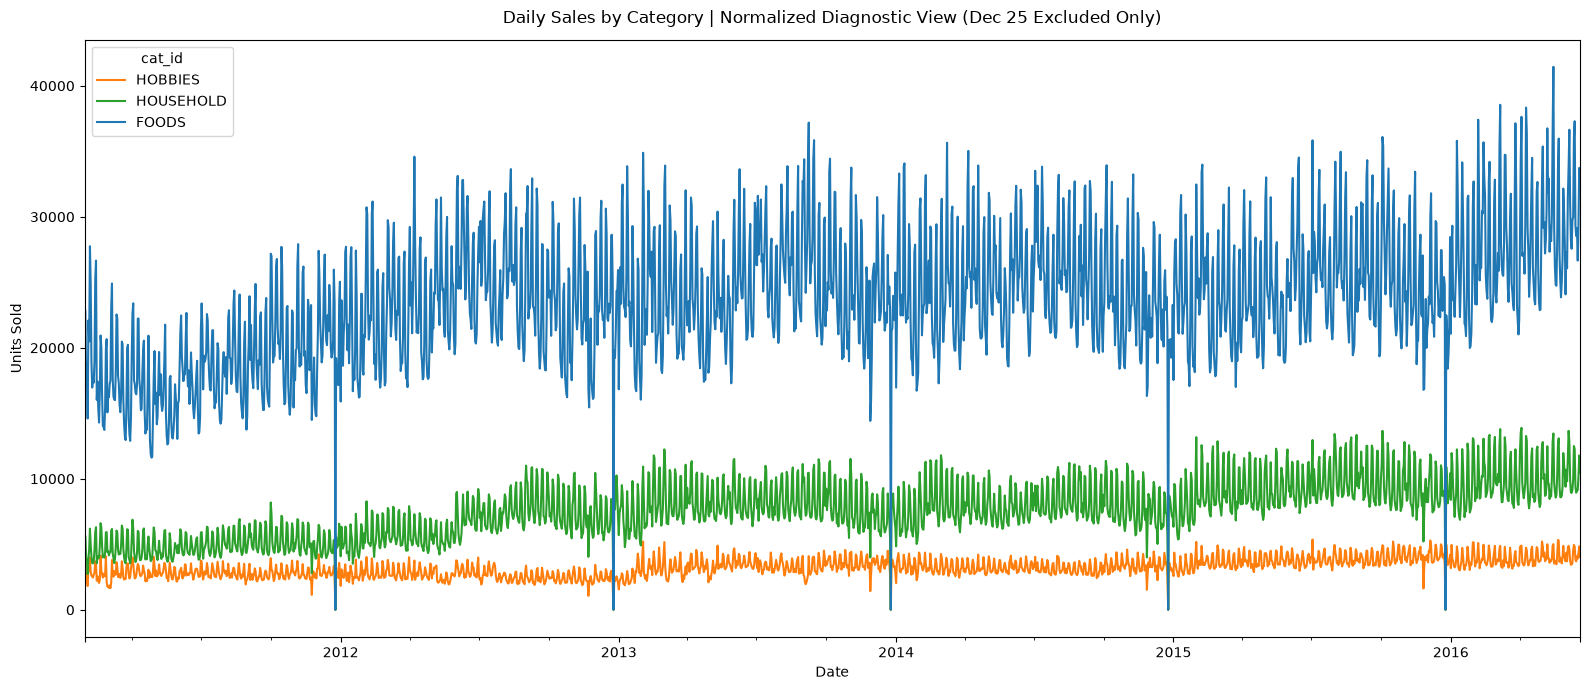

In [ ]:
plot_category_multiline(category_daily_event_enriched, title="Daily Sales by Category | Normalized Diagnostic View (Dec 25 Excluded Only)")

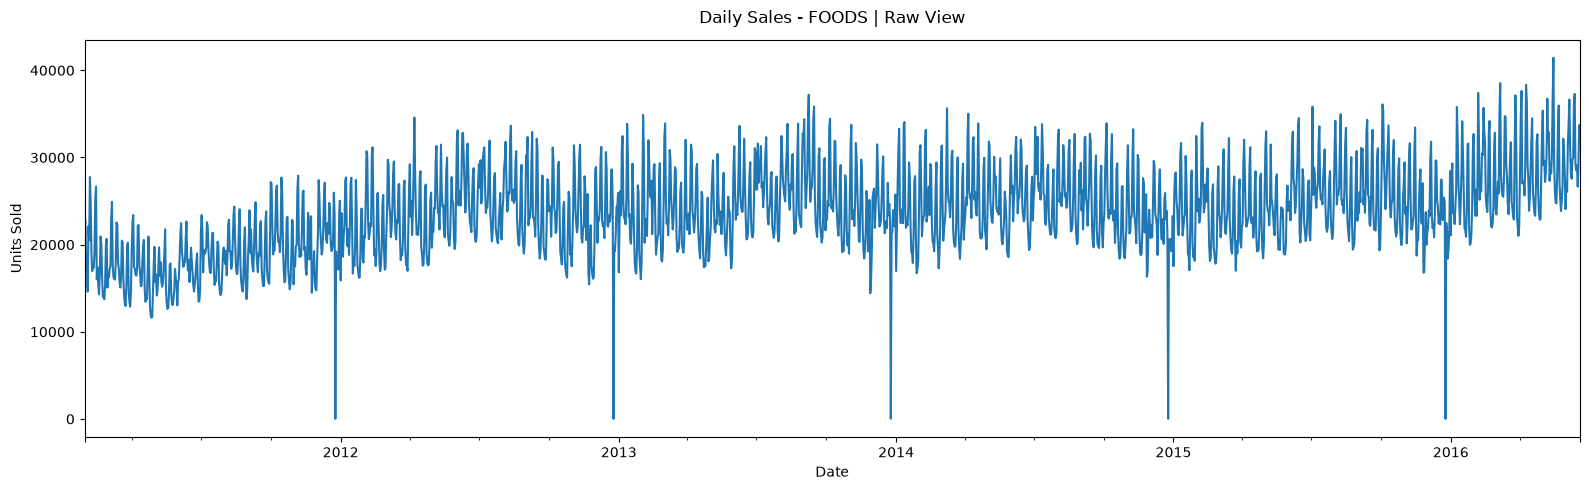

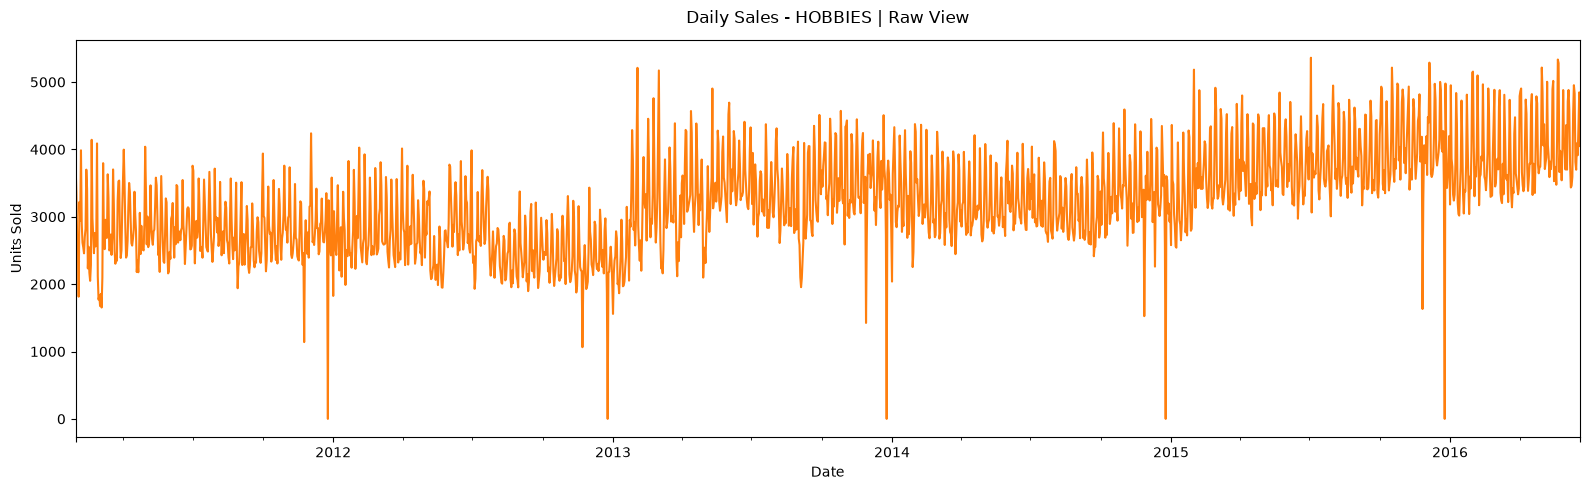

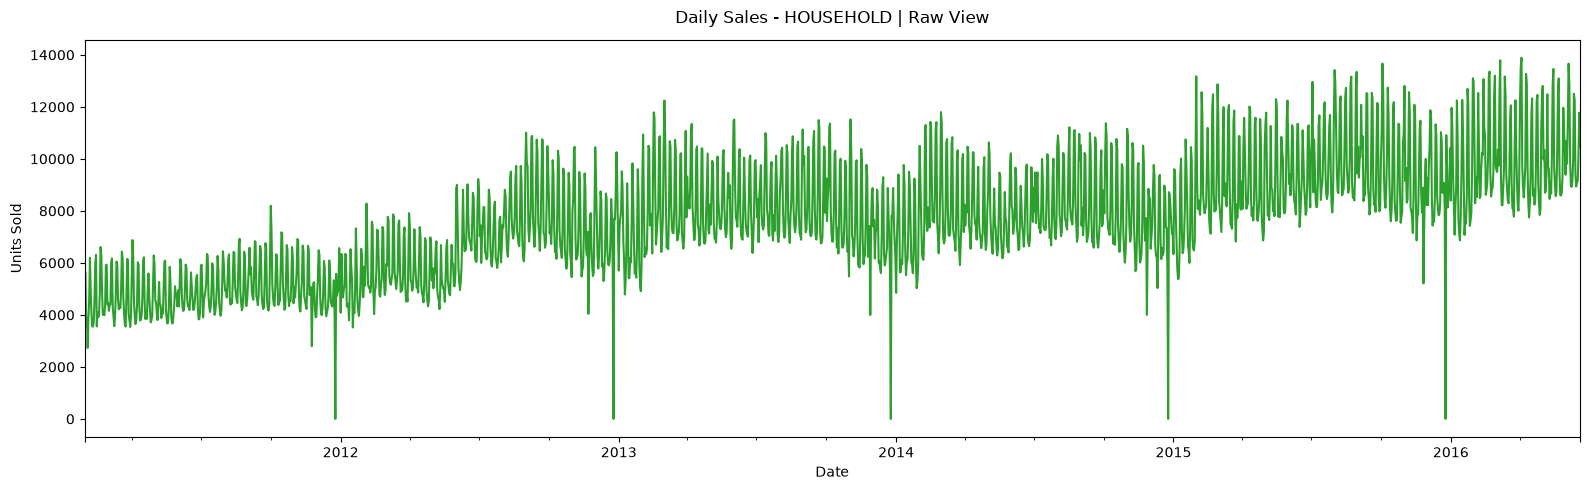

In [ ]:
plot_category_panels(category_daily_event_enriched, title_suffix="Raw View")

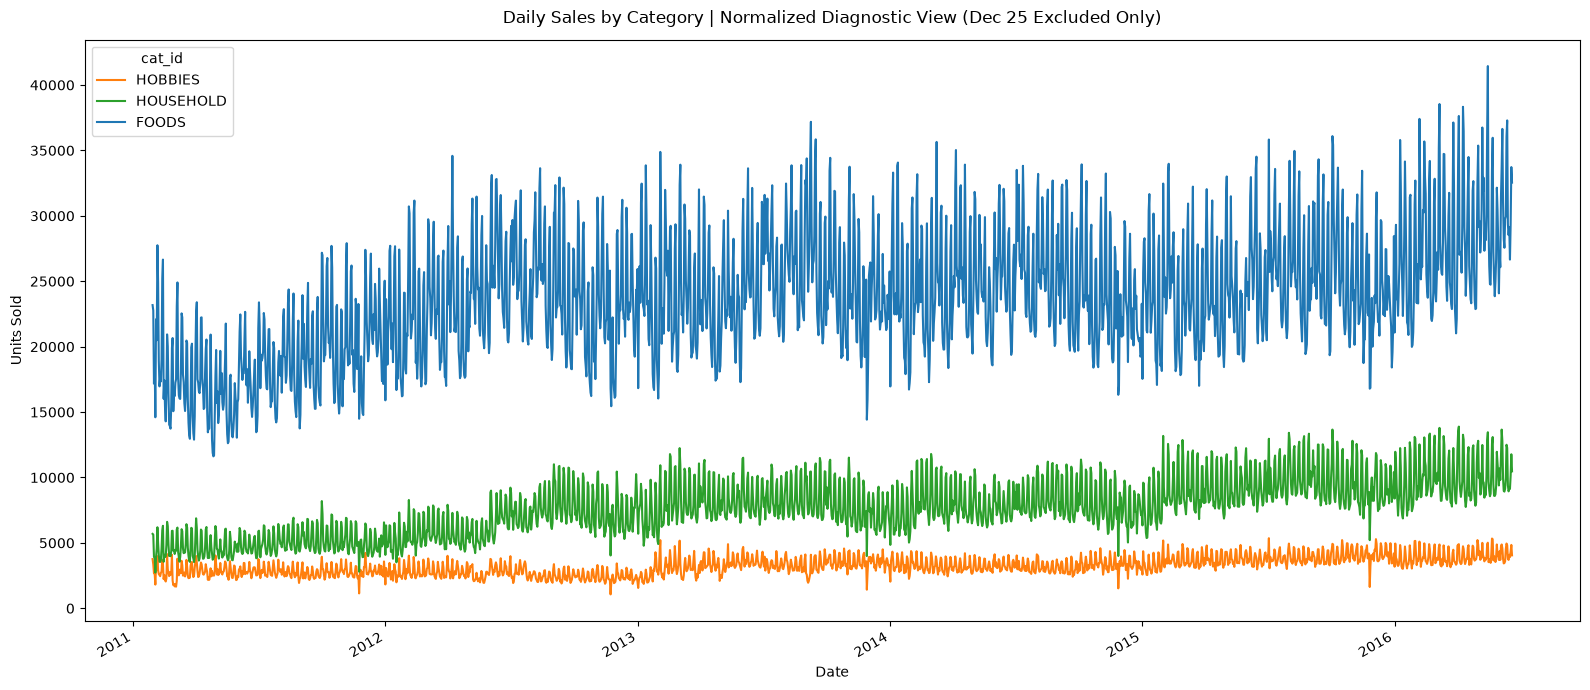

In [ ]:
plot_category_multiline(category_daily_normalized, title="Daily Sales by Category | Normalized Diagnostic View (Dec 25 Excluded Only)")

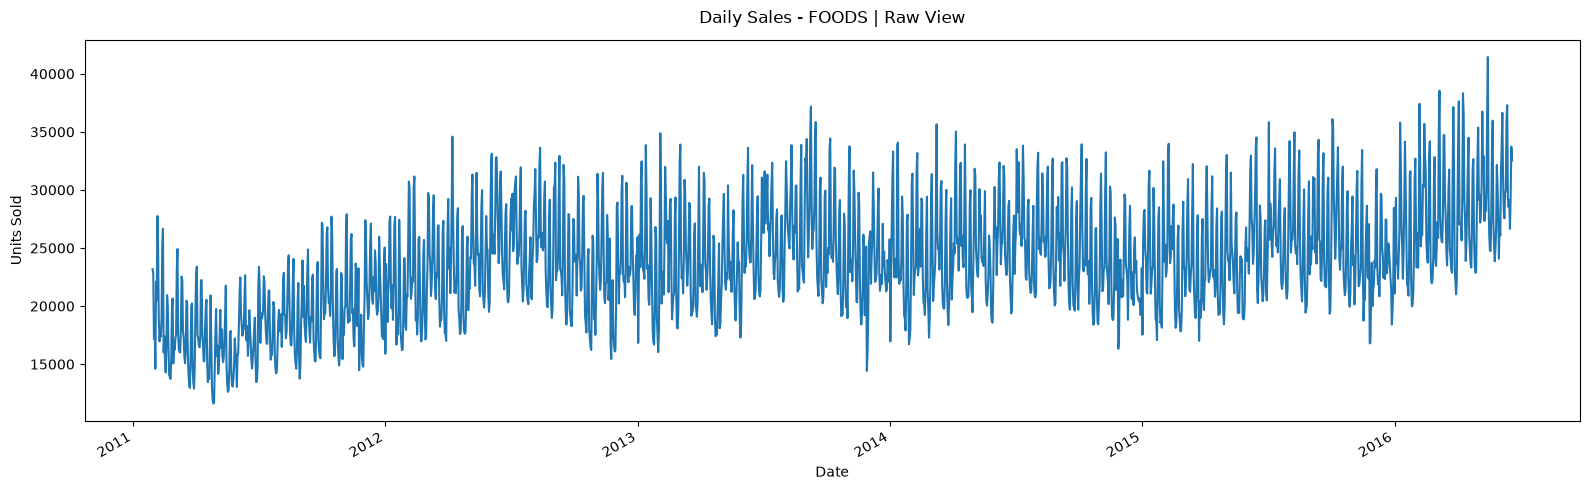

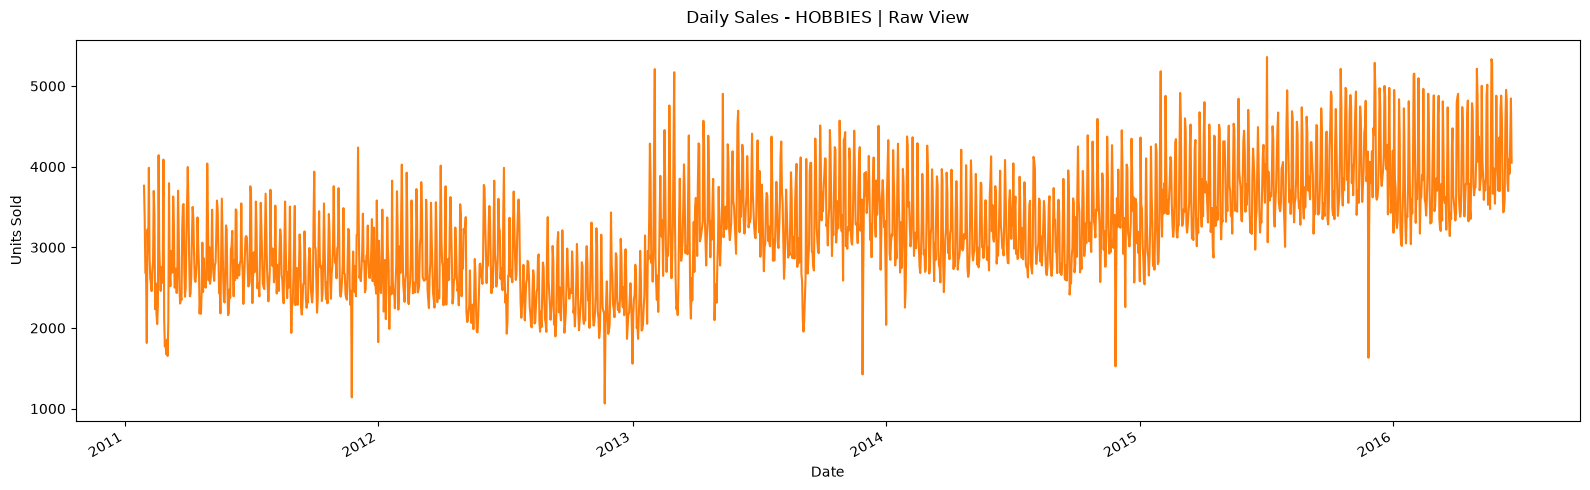

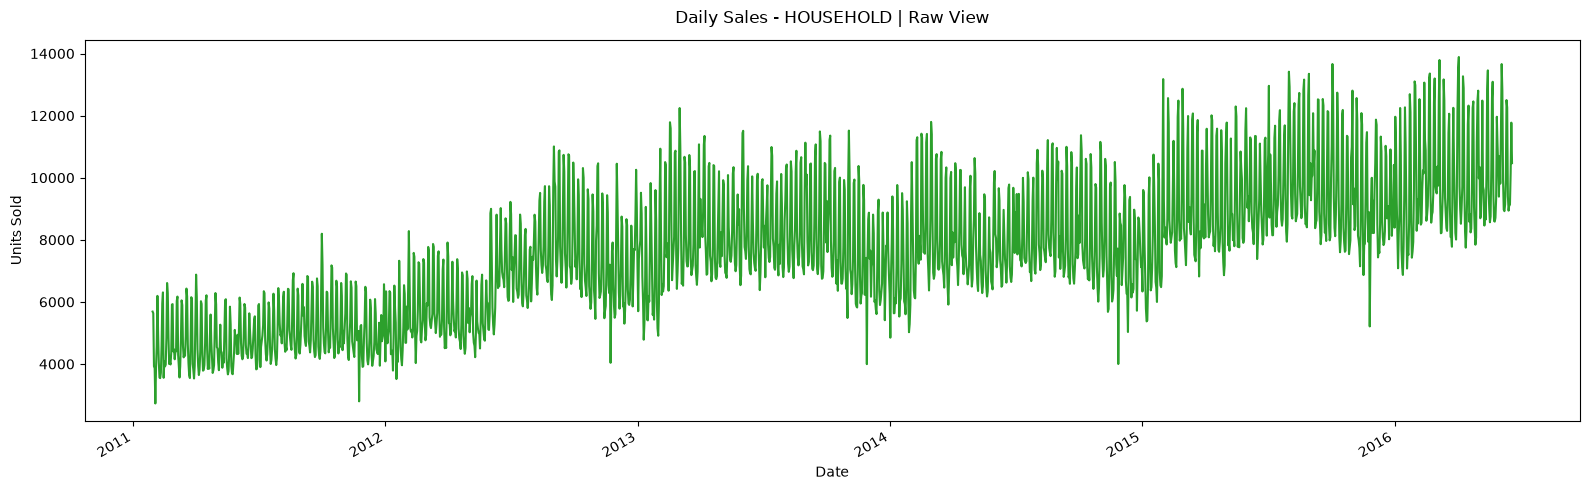

In [ ]:
plot_category_panels(category_daily_normalized, title_suffix="Raw View")

## 8. Extreme low-sales days and holiday diagnostics

This section asks whether unusually low category days look like data errors, predictable holiday behavior, or narrower store-level effects. The goal is diagnosis, not a final causal claim.


In [ ]:
zero_category_days = category_daily_raw.loc[category_daily_raw["y"].eq(0)].copy()

print("Zero category-day observations:", len(zero_category_days))
zero_category_days.sort_values(["ds", "cat_id"])


Zero category-day observations: 9


,ds,cat_id,y
990,2011-12-25,HOBBIES,0.0
991,2011-12-25,HOUSEHOLD,0.0
2088,2012-12-25,HOBBIES,0.0
2089,2012-12-25,HOUSEHOLD,0.0
3183,2013-12-25,HOBBIES,0.0
3184,2013-12-25,HOUSEHOLD,0.0
4278,2014-12-25,HOBBIES,0.0
4279,2014-12-25,HOUSEHOLD,0.0
5373,2015-12-25,HOBBIES,0.0


In [ ]:
low_sales_days = (
    category_daily_event_enriched
    .assign(
        p01_by_category=lambda df: (
            df.groupby("cat_id", observed=True)["y"]
            .transform(lambda s: s.quantile(0.01))
        )
    )
    .loc[lambda df: df["y"] <= df["p01_by_category"]]
    .sort_values(["cat_id", "y", "ds"])
)

low_sales_days


,ds,cat_id,y,event_name_1,event_type_1,event_name_2,event_type_2,year,month,day,dayofweek,weekofyear,is_christmas,is_christmas_eve,is_day_after_christmas,is_new_years_day,is_thanksgiving_window,p01_by_category
330,2011-12-25,HOBBIES,0.0,Christmas,National,nan,nan,2011,12,25,Sunday,51,True,False,False,False,False,1872.48
696,2012-12-25,HOBBIES,0.0,Christmas,National,nan,nan,2012,12,25,Tuesday,52,True,False,False,False,False,1872.48
1061,2013-12-25,HOBBIES,0.0,Christmas,National,nan,nan,2013,12,25,Wednesday,52,True,False,False,False,False,1872.48
1426,2014-12-25,HOBBIES,0.0,Christmas,National,nan,nan,2014,12,25,Thursday,52,True,False,False,False,False,1872.48
1791,2015-12-25,HOBBIES,0.0,Christmas,National,nan,nan,2015,12,25,Friday,52,True,False,False,False,False,1872.48
663,2012-11-22,HOBBIES,1064.0,Thanksgiving,National,nan,nan,2012,11,22,Thursday,47,False,False,False,False,True,1872.48
299,2011-11-24,HOBBIES,1140.0,Thanksgiving,National,nan,nan,2011,11,24,Thursday,47,False,False,False,False,True,1872.48
1034,2013-11-28,HOBBIES,1424.0,Thanksgiving,National,nan,nan,2013,11,28,Thursday,48,False,False,False,False,True,1872.48
1398,2014-11-27,HOBBIES,1525.0,Thanksgiving,National,nan,nan,2014,11,27,Thursday,48,False,False,False,False,True,1872.48
703,2013-01-01,HOBBIES,1558.0,NewYear,National,nan,nan,2013,1,1,Tuesday,1,False,False,False,True,False,1872.48


In [ ]:
christmas_impact = (
    category_daily_event_enriched
    .groupby(["cat_id", "is_christmas"], observed=True)["y"]
    .agg(count="count", mean="mean", median="median", min="min", max="max")
    .reset_index()
)

christmas_impact_pivot = (
    christmas_impact
    .pivot(index="cat_id", columns="is_christmas", values="mean")
    .rename(columns={False: "normal_avg_sales", True: "christmas_avg_sales"})
)

christmas_impact_pivot["christmas_sales_retention"] = (
    christmas_impact_pivot["christmas_avg_sales"] / christmas_impact_pivot["normal_avg_sales"]
)
christmas_impact_pivot["christmas_sales_drop_pct"] = 1 - christmas_impact_pivot["christmas_sales_retention"]

christmas_impact_pivot.round(3)


is_christmas,normal_avg_sales,christmas_avg_sales,christmas_sales_retention,christmas_sales_drop_pct
cat_id,,,,
HOBBIES,3236.239014,0.0,0.000,1.000
HOUSEHOLD,7663.341797,0.2,0.000,1.000
FOODS,23803.187500,15.4,0.001,0.999


In [ ]:
# Drill deeper into Christmas to avoid assuming that all stores are simply "closed."
christmas_detail = m5.loc[
    m5["ds"].dt.month.eq(12)
    & m5["ds"].dt.day.eq(25)
    & m5["y"].gt(0)
].copy()

christmas_store_sales = (
    christmas_detail
    .assign(year=lambda df: df["ds"].dt.year)
    .groupby(["year", "cat_id", "state_id", "store_id"], observed=True)
    .agg(
        total_sales=("y", "sum"),
        selling_items=("item_id", "nunique"),
        selling_series=("unique_id", "nunique"),
    )
    .reset_index()
    .sort_values(["year", "cat_id", "total_sales"], ascending=[True, True, False])
)

christmas_store_sales.head(20)


,year,cat_id,state_id,store_id,total_sales,selling_items,selling_series
0,2011,FOODS,CA,CA_2,7.0,2,2
3,2011,FOODS,WI,WI_2,3.0,3,3
2,2011,FOODS,TX,TX_3,2.0,2,2
1,2011,FOODS,CA,CA_3,1.0,1,1
5,2012,FOODS,CA,CA_3,4.0,4,4
7,2012,FOODS,WI,WI_2,3.0,3,3
4,2012,FOODS,CA,CA_2,2.0,2,2
6,2012,FOODS,TX,TX_3,2.0,2,2
11,2013,FOODS,TX,TX_2,11.0,4,4
9,2013,FOODS,CA,CA_3,3.0,2,2


In [ ]:
christmas_category_summary = (
    christmas_store_sales
    .groupby(["year", "cat_id"], observed=True)
    .agg(
        stores_with_sales=("store_id", "nunique"),
        total_christmas_sales=("total_sales", "sum"),
        total_selling_items=("selling_items", "sum"),
        total_selling_series=("selling_series", "sum"),
    )
    .reset_index()
)

christmas_category_summary


,year,cat_id,stores_with_sales,total_christmas_sales,total_selling_items,total_selling_series
0,2011,FOODS,4,13.0,8,8
1,2012,FOODS,4,11.0,11,11
2,2013,FOODS,7,20.0,12,12
3,2014,FOODS,4,20.0,17,17
4,2015,HOUSEHOLD,1,1.0,1,1
5,2015,FOODS,7,13.0,11,11


In [ ]:
thanksgiving_impact = (
    category_daily_event_enriched
    .groupby(["cat_id", "is_thanksgiving_window"], observed=True)["y"]
    .agg(count="count", mean="mean", median="median", min="min", max="max")
    .reset_index()
)

thanksgiving_impact


,cat_id,is_thanksgiving_window,count,mean,median,min,max
0,HOBBIES,False,1934,3233.816895,3205.5,0.0,5360.0
1,HOBBIES,True,35,2907.771484,2948.0,1064.0,4817.0
2,HOUSEHOLD,False,1934,7658.921387,7514.5,0.0,13889.0
3,HOUSEHOLD,True,35,6812.856934,6695.0,2798.0,11469.0
4,FOODS,False,1934,23802.880859,23443.5,11.0,41447.0
5,FOODS,True,35,20421.828125,20047.0,14419.0,28639.0


### Working interpretation

December 25 should not automatically be treated as bad data or confirmed store closure. The raw data keeps those observations, and some sales still appear on that date. For this notebook, December 25 is excluded only in `category_daily_normalized`, which is a diagnostic view for studying typical demand without one extreme holiday dominating the scale.


## 9. Sales distribution analysis

Distribution views help show how different the categories are in scale and spread. The raw view reflects real operating behavior, while the normalized view helps us inspect the shape of ordinary demand after removing December 25 from that one diagnostic slice.


In [ ]:
category_summary_raw = (
    category_daily_raw
    .groupby("cat_id", observed=True)["y"]
    .agg(count="count", mean="mean", median="median", std="std", skew="skew", min="min", max="max")
    .round(2)
)

category_summary_raw


,count,mean,median,std,skew,min,max
cat_id,,,,,,,
HOBBIES,1969,3228.020020,3203.0,718.739990,0.13,0.0,5360.0
HOUSEHOLD,1969,7643.879883,7494.0,2222.209961,0.22,0.0,13889.0
FOODS,1969,23742.779297,23377.0,4990.160156,0.02,11.0,41447.0


In [ ]:
category_summary_normalized = (
    category_daily_normalized
    .groupby("cat_id", observed=True)["y"]
    .agg(count="count", mean="mean", median="median", std="std", skew="skew", min="min", max="max")
    .round(2)
)

category_summary_normalized


,count,mean,median,std,skew,min,max
cat_id,,,,,,,
HOBBIES,1964,3236.239990,3204.5,700.919983,0.35,1064.0,5360.0
HOUSEHOLD,1964,7663.339844,7504.0,2191.260010,0.31,2729.0,13889.0
FOODS,1964,23803.189453,23386.0,4850.509766,0.28,11616.0,41447.0


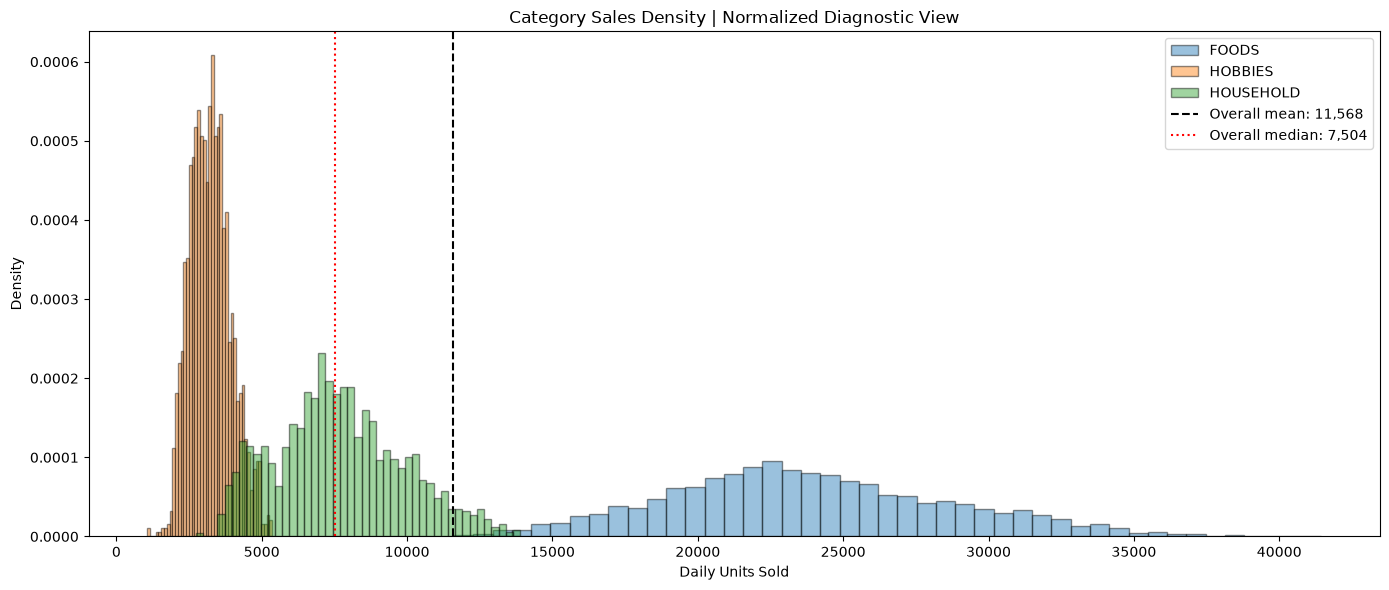

In [ ]:
overall_mean = category_daily_normalized["y"].mean()
overall_median = category_daily_normalized["y"].median()

CATEGORY_COLORS = {
    "FOODS": "tab:blue",
    "HOBBIES": "tab:orange",
    "HOUSEHOLD": "tab:green",
}

plt.figure(figsize=(14, 6))

for cat in sorted(category_daily_normalized["cat_id"].unique()):
    data = category_daily_normalized.loc[category_daily_normalized["cat_id"].eq(cat), "y"]
    plt.hist(
        data,
        bins="sqrt",
        density=True,
        alpha=0.45,
        edgecolor="black",
        label=cat,
        color=CATEGORY_COLORS.get(cat, "tab:gray"),
    )

plt.axvline(overall_mean, color="black", linestyle="--", label=f"Overall mean: {overall_mean:,.0f}")
plt.axvline(overall_median, color="red", linestyle=":", label=f"Overall median: {overall_median:,.0f}")
plt.title("Category Sales Density | Normalized Diagnostic View")
plt.xlabel("Daily Units Sold")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


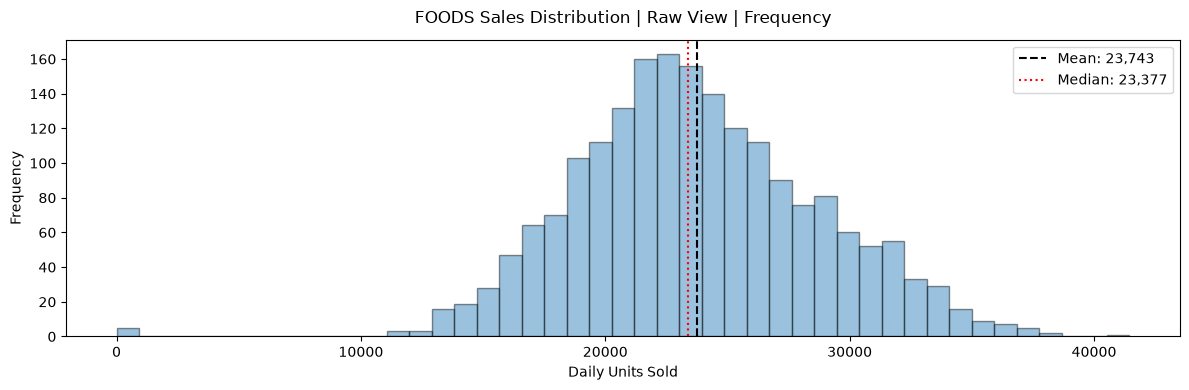

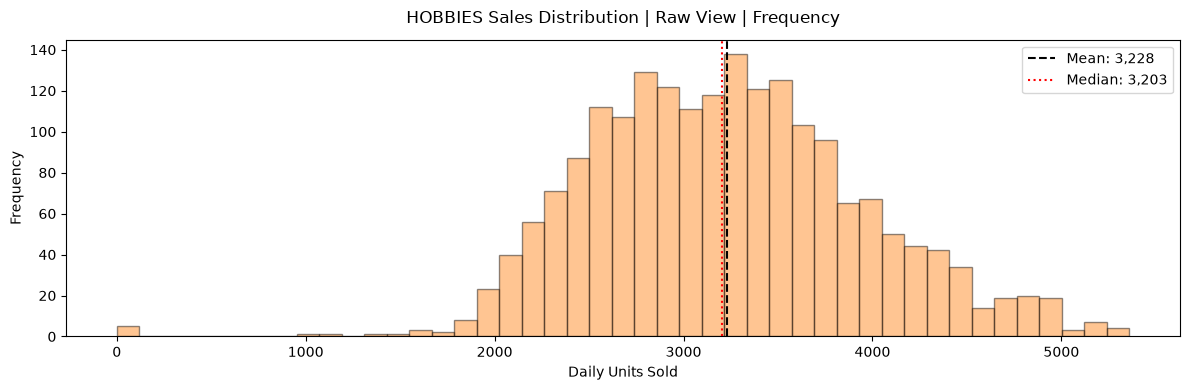

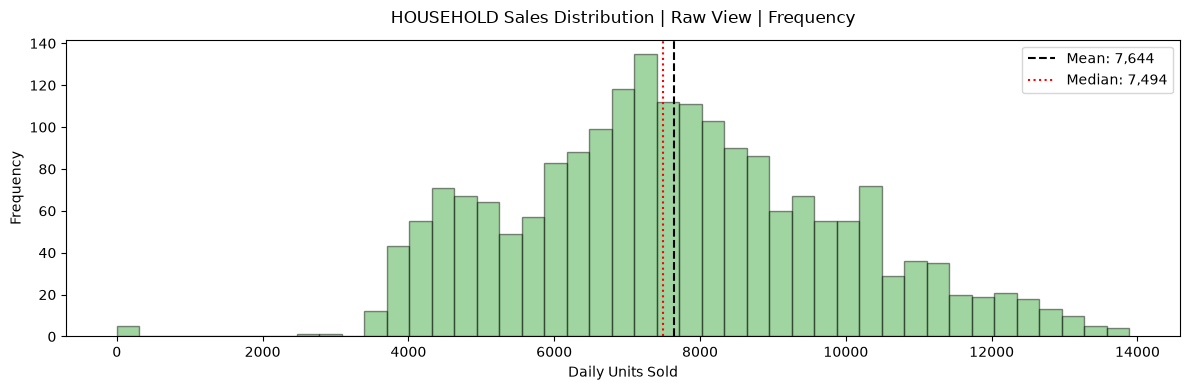

In [ ]:
plot_category_histograms(category_daily_raw, title_suffix="Raw View", density=False)


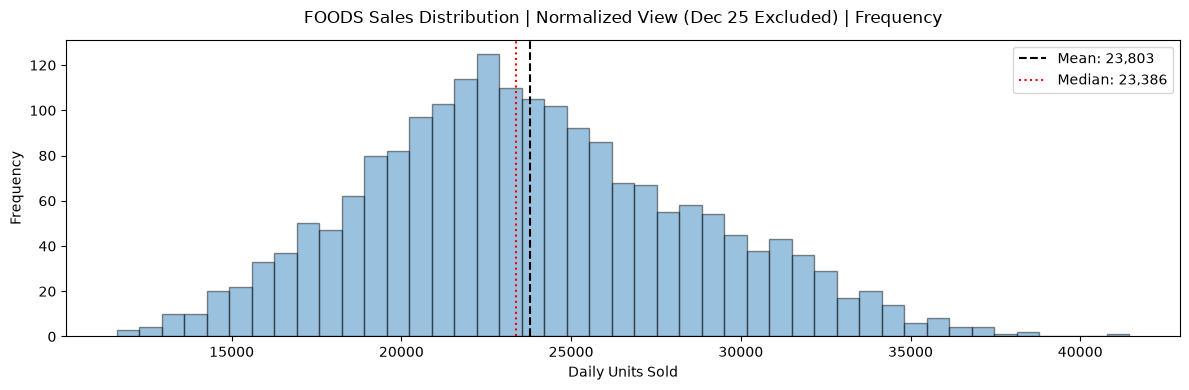

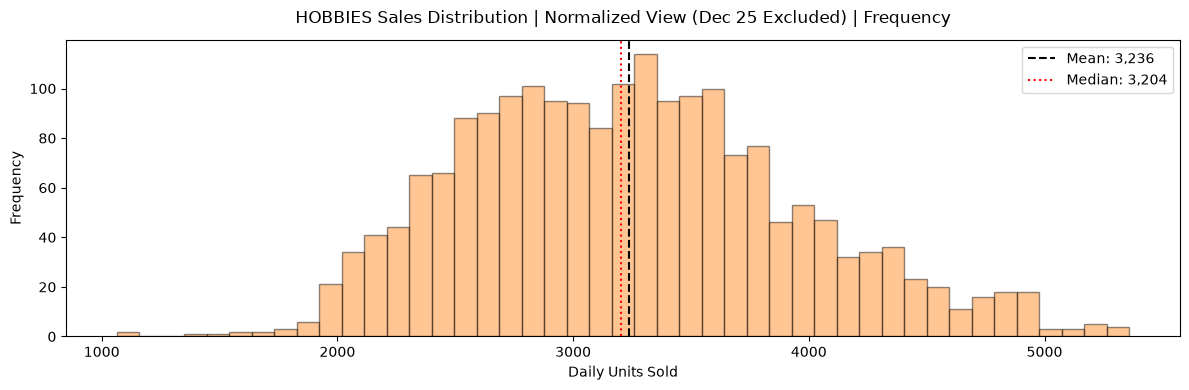

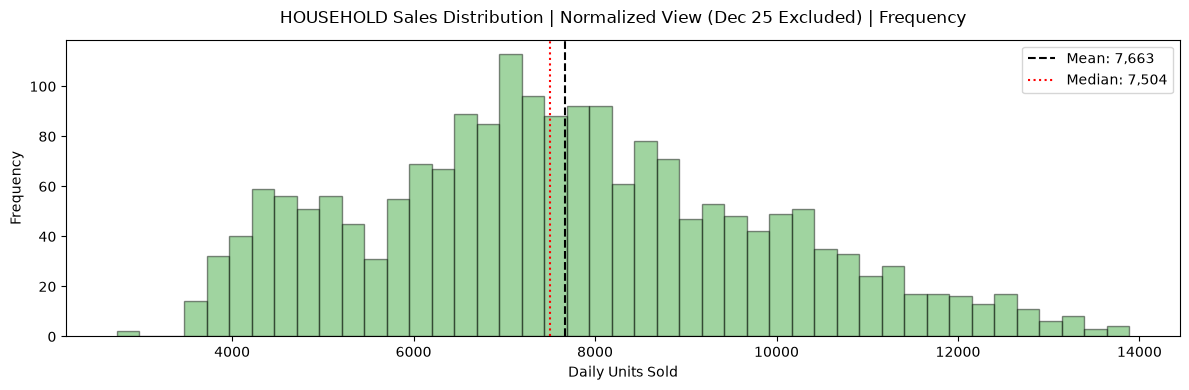

In [ ]:
plot_category_histograms(category_daily_normalized, title_suffix="Normalized View (Dec 25 Excluded)", density=False)


### Distribution interpretation

The category distributions are not interchangeable. `FOODS` operates at a much larger daily scale than `HOBBIES` or `HOUSEHOLD`, so category-level normalization and category-specific evaluation will matter later.


## 10. Seasonality diagnostics

Seasonality is more useful when viewed by category instead of only in the aggregate. This prevents the highest-volume category from dominating the interpretation.


In [ ]:
seasonality_df = add_calendar_flags(category_daily_raw)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

category_dow_sales = (
    seasonality_df
    .groupby(["cat_id", "dayofweek"], observed=True)["y"]
    .mean()
    .reset_index()
)
category_dow_sales["dayofweek"] = pd.Categorical(
    category_dow_sales["dayofweek"],
    categories=weekday_order,
    ordered=True,
)
category_dow_sales = category_dow_sales.sort_values(["cat_id", "dayofweek"])

category_dow_sales


,cat_id,dayofweek,y
1,HOBBIES,Monday,3004.021240
5,HOBBIES,Tuesday,2874.975098
6,HOBBIES,Wednesday,2907.932373
4,HOBBIES,Thursday,2902.508789
0,HOBBIES,Friday,3348.491211
2,HOBBIES,Saturday,3960.684326
3,HOBBIES,Sunday,3593.627686
8,HOUSEHOLD,Monday,7209.740234
12,HOUSEHOLD,Tuesday,6576.711914
13,HOUSEHOLD,Wednesday,6501.071289


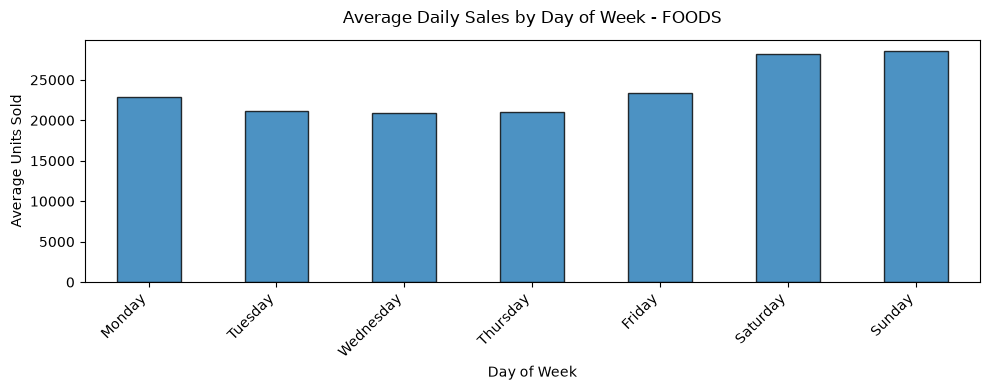

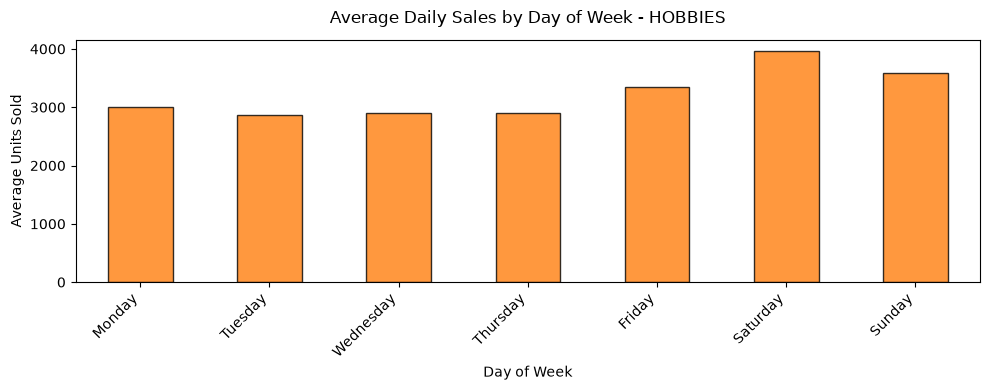

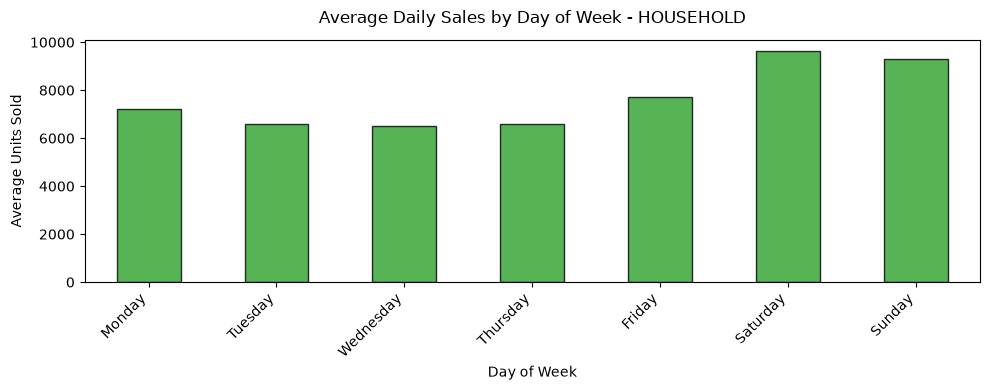

In [ ]:
plot_category_bar_panels(
    category_dow_sales,
    x_col="dayofweek",
    y_col="y",
    title_prefix="Average Daily Sales by Day of Week",
    xlabel="Day of Week",
    ylabel="Average Units Sold",
    rotation=45,
)


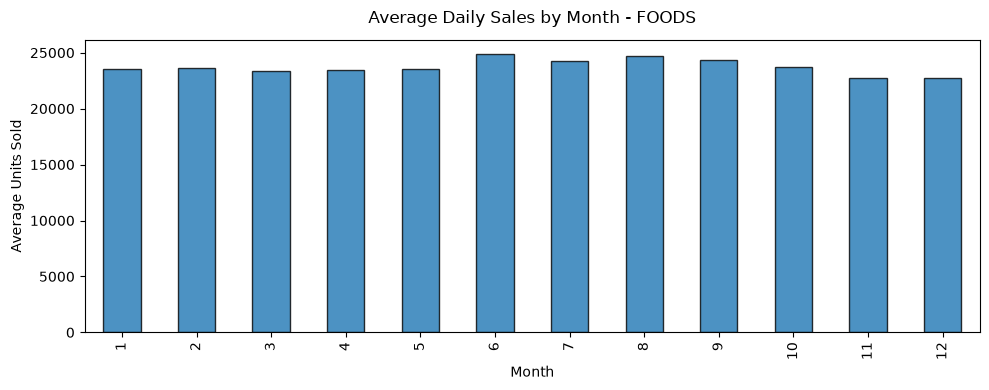

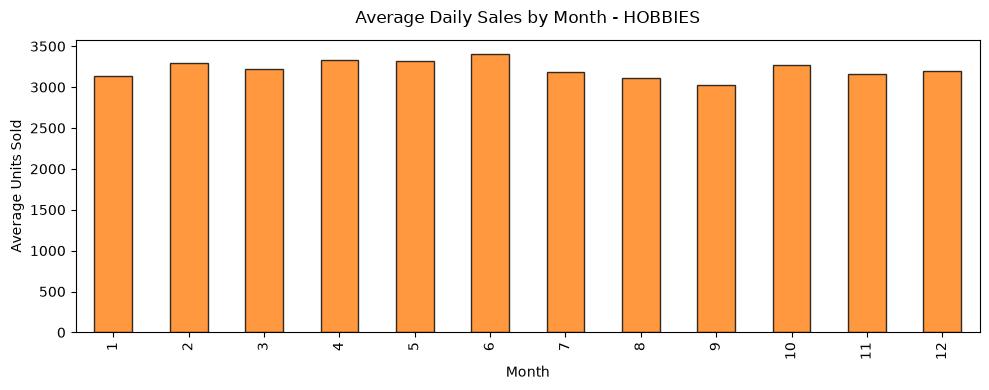

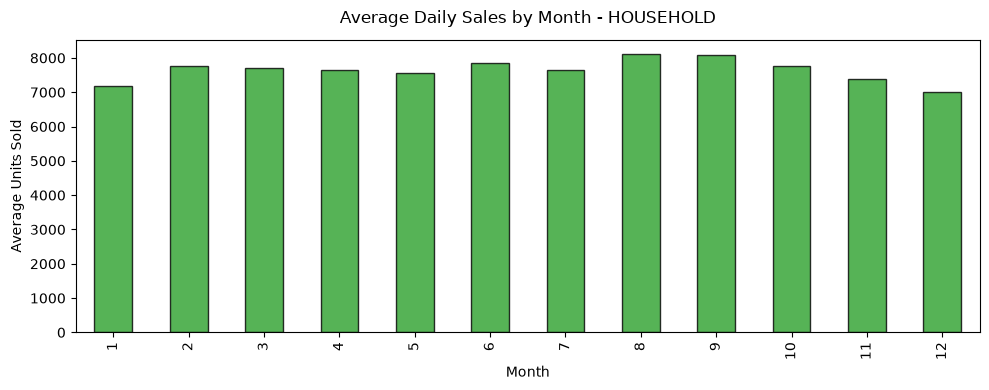

In [ ]:
category_monthly_sales = (
    seasonality_df
    .groupby(["cat_id", "month"], observed=True)["y"]
    .mean()
    .reset_index()
)

plot_category_bar_panels(
    category_monthly_sales,
    x_col="month",
    y_col="y",
    title_prefix="Average Daily Sales by Month",
    xlabel="Month",
    ylabel="Average Units Sold",
)


## 11. Event and SNAP first pass

This section is intentionally light-touch. We only want a first look at event and SNAP context now. Deeper interpretation belongs in feature engineering, where we can evaluate whether these fields improve forecasts or inventory decisions.


In [ ]:
event_sales = (
    m5
    .groupby(["cat_id", "event_type_1"], observed=True)["y"]
    .agg(mean="mean", median="median", count="count")
    .reset_index()
    .sort_values(["cat_id", "mean"], ascending=[True, False])
)

event_sales


,cat_id,event_type_1,mean,median,count
4,HOBBIES,nan,0.715822,0.0,8205696
2,HOBBIES,Religious,0.714942,0.0,248311
3,HOBBIES,Sporting,0.710341,0.0,80971
0,HOBBIES,Cultural,0.705313,0.0,166675
1,HOBBIES,National,0.543252,0.0,238473
8,HOUSEHOLD,Sporting,0.917914,0.0,150086
9,HOUSEHOLD,nan,0.914441,0.0,15185146
7,HOUSEHOLD,Religious,0.904584,0.0,461537
5,HOUSEHOLD,Cultural,0.883854,0.0,310100
6,HOUSEHOLD,National,0.761730,0.0,440492


In [ ]:
snap_cols = ["snap_CA", "snap_TX", "snap_WI"]

snap_effects = []
for state, snap_col in zip(["CA", "TX", "WI"], snap_cols):
    tmp = (
        m5.loc[m5["state_id"].eq(state)]
        .groupby(["cat_id", snap_col], observed=True)["y"]
        .agg(mean="mean", median="median", count="count")
        .reset_index()
        .rename(columns={snap_col: "snap_flag"})
    )
    tmp["state_id"] = state
    tmp["snap_col"] = snap_col
    snap_effects.append(tmp)

snap_effects = pd.concat(snap_effects, ignore_index=True)
snap_effects.sort_values(["state_id", "cat_id", "snap_flag"])


,cat_id,snap_flag,mean,median,count,state_id,snap_col
0,HOBBIES,0,0.878451,0.0,2379626,CA,snap_CA
1,HOBBIES,1,0.907639,0.0,1168172,CA,snap_CA
2,HOUSEHOLD,0,1.002669,0.0,4417787,CA,snap_CA
3,HOUSEHOLD,1,1.042090,0.0,2170055,CA,snap_CA
4,FOODS,0,2.201591,1.0,5852271,CA,snap_CA
5,FOODS,1,2.431755,1.0,2876254,CA,snap_CA
6,HOBBIES,0,0.609812,0.0,1805429,TX,snap_TX
7,HOBBIES,1,0.624143,0.0,888315,TX,snap_TX
8,HOUSEHOLD,0,0.893040,0.0,3348930,TX,snap_TX
9,HOUSEHOLD,1,0.924090,0.0,1647997,TX,snap_TX


## 12. SKU-store intermittency and demand profile

Category demand can look smooth even when the underlying SKU-store series are sparse. This matters for retail replenishment because operational decisions happen closer to the series level than the category level.


In [ ]:
series_profile = (
    m5
    .groupby("unique_id", observed=True)
    .agg(
        avg_daily_sales=("y", "mean"),
        median_daily_sales=("y", "median"),
        total_sales=("y", "sum"),
        zero_sales_rate=("y", lambda s: (s == 0).mean()),
        sales_std=("y", "std"),
        days_observed=("y", "count"),
    )
    .reset_index()
    .merge(S_df, on="unique_id", how="left")
)

series_profile.head()


,unique_id,avg_daily_sales,median_daily_sales,total_sales,zero_sales_rate,sales_std,days_observed,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,0.797359,0.0,1570.0,0.561199,1.271991,1969,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1,FOODS_1_001_CA_2,1.161503,1.0,2287.0,0.483494,1.779034,1969,FOODS_1_001,FOODS_1,FOODS,CA_2,CA
2,FOODS_1_001_CA_3,1.202133,0.0,2367.0,0.547994,2.329288,1969,FOODS_1_001,FOODS_1,FOODS,CA_3,CA
3,FOODS_1_001_CA_4,0.361789,0.0,712.0,0.740854,0.734233,1968,FOODS_1_001,FOODS_1,FOODS,CA_4,CA
4,FOODS_1_001_TX_1,0.588415,0.0,1158.0,0.668191,1.312142,1968,FOODS_1_001,FOODS_1,FOODS,TX_1,TX


In [ ]:
def demand_type(row):
    if row["zero_sales_rate"] >= 0.70:
        return "Very intermittent"
    if row["zero_sales_rate"] >= 0.40:
        return "Intermittent"
    if row["avg_daily_sales"] >= 5:
        return "High volume"
    return "Regular / low volume"


series_profile["demand_type"] = series_profile.apply(demand_type, axis=1)

series_profile["demand_type"].value_counts()


demand_type
Very intermittent       12293
Intermittent            11477
Regular / low volume     5329
High volume              1391
Name: count, dtype: int64

In [ ]:
series_profile_by_category = (
    series_profile
    .groupby(["cat_id", "demand_type"], observed=True)
    .agg(
        series_count=("unique_id", "nunique"),
        avg_zero_rate=("zero_sales_rate", "mean"),
        avg_daily_sales=("avg_daily_sales", "mean"),
    )
    .reset_index()
    .sort_values(["cat_id", "series_count"], ascending=[True, False])
)

series_profile_by_category


,cat_id,demand_type,series_count,avg_zero_rate,avg_daily_sales
3,HOBBIES,Very intermittent,3582,0.843853,0.220303
1,HOBBIES,Intermittent,1604,0.571955,0.918031
2,HOBBIES,Regular / low volume,378,0.305261,2.443355
0,HOBBIES,High volume,86,0.252088,7.015189
7,HOUSEHOLD,Very intermittent,5134,0.832203,0.220296
5,HOUSEHOLD,Intermittent,3466,0.566625,0.784415
6,HOUSEHOLD,Regular / low volume,1599,0.271079,2.174611
4,HOUSEHOLD,High volume,271,0.115719,8.445720
9,FOODS,Intermittent,6407,0.552882,1.031018
11,FOODS,Very intermittent,3577,0.794132,0.327558


### Intermittency visual checks

These plots translate the table summaries into a more intuitive EDA view:

- how many SKU-store series fall into each demand profile
- how severe average zero-sales behavior is by category


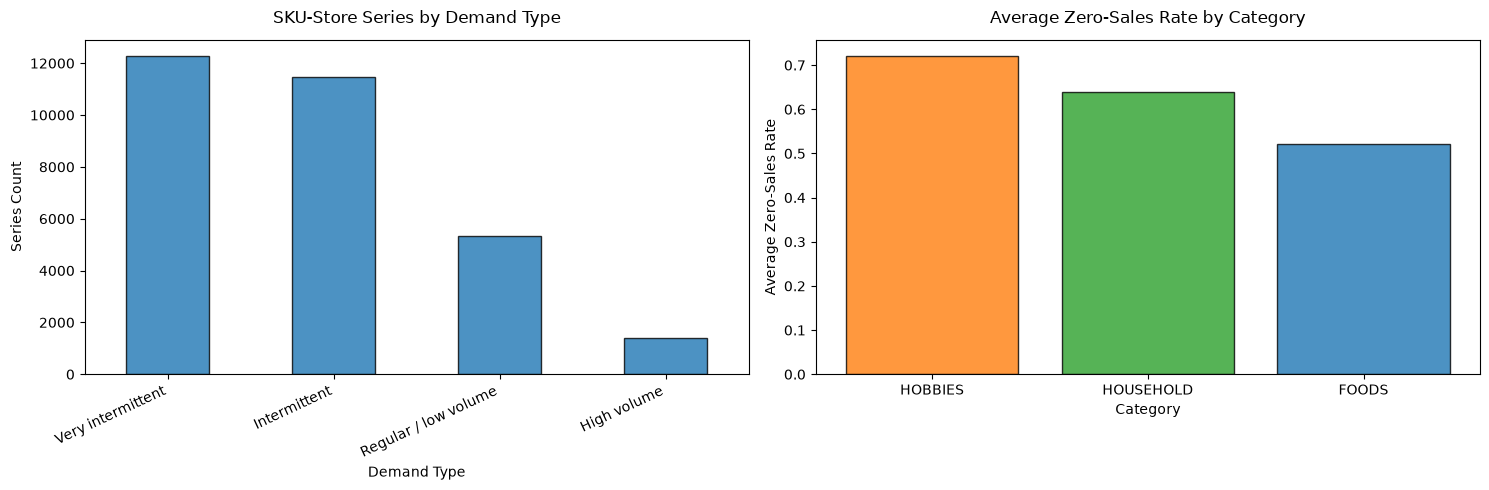

,cat_id,avg_zero_sales_rate,median_zero_sales_rate,series_count
0,HOBBIES,0.721622,0.776871,5650
1,HOUSEHOLD,0.640045,0.693576,10470
2,FOODS,0.520757,0.537344,14370


In [ ]:
demand_type_order = [
    "Very intermittent",
    "Intermittent",
    "Regular / low volume",
    "High volume",
]

demand_type_counts = (
    series_profile["demand_type"]
    .value_counts()
    .reindex(demand_type_order, fill_value=0)
)

zero_rate_by_category = (
    series_profile
    .groupby("cat_id", observed=True)
    .agg(
        avg_zero_sales_rate=("zero_sales_rate", "mean"),
        median_zero_sales_rate=("zero_sales_rate", "median"),
        series_count=("unique_id", "nunique"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

demand_type_counts.plot(
    kind="bar",
    ax=axes[0],
    color="tab:blue",
    edgecolor="black",
    alpha=0.80,
)
finish_axis(
    axes[0],
    title="SKU-Store Series by Demand Type",
    xlabel="Demand Type",
    ylabel="Series Count",
    rotation=25,
)

axes[1].bar(
    zero_rate_by_category["cat_id"],
    zero_rate_by_category["avg_zero_sales_rate"],
    color=[CATEGORY_COLORS.get(cat, "tab:gray") for cat in zero_rate_by_category["cat_id"]],
    edgecolor="black",
    alpha=0.80,
)
finish_axis(
    axes[1],
    title="Average Zero-Sales Rate by Category",
    xlabel="Category",
    ylabel="Average Zero-Sales Rate",
)

plt.show()

zero_rate_by_category


## 13. Price behavior

Price is part of the exogenous signal. At this stage, we only want a descriptive view of how much price movement exists and what one high-volume series looks like over time.


In [ ]:
price_profile = (
    m5
    .groupby("unique_id", observed=True)
    .agg(
        avg_price=("sell_price", "mean"),
        min_price=("sell_price", "min"),
        max_price=("sell_price", "max"),
        price_changes=("sell_price", "nunique"),
        total_sales=("y", "sum"),
    )
    .reset_index()
    .merge(S_df, on="unique_id", how="left")
)

price_profile.sort_values("price_changes", ascending=False).head(20)


,unique_id,avg_price,min_price,max_price,price_changes,total_sales,item_id,dept_id,cat_id,store_id,state_id
936,FOODS_1_095_TX_3,4.113125,3.44,4.62,21,1828.0,FOODS_1_095,FOODS_1,FOODS,TX_3,TX
934,FOODS_1_095_TX_1,4.118389,3.44,4.62,21,280.0,FOODS_1_095,FOODS_1,FOODS,TX_1,TX
1267,FOODS_1_129_WI_1,7.995534,5.04,9.00,20,2497.0,FOODS_1_129,FOODS_1,FOODS,WI_1,WI
935,FOODS_1_095_TX_2,4.104251,3.44,4.62,18,811.0,FOODS_1_095,FOODS_1,FOODS,TX_2,TX
930,FOODS_1_095_CA_1,3.026816,2.66,3.42,18,403.0,FOODS_1_095,FOODS_1,FOODS,CA_1,CA
931,FOODS_1_095_CA_2,3.026387,2.66,3.42,18,915.0,FOODS_1_095,FOODS_1,FOODS,CA_2,CA
1269,FOODS_1_129_WI_3,8.033463,5.04,9.00,18,2994.0,FOODS_1_129,FOODS_1,FOODS,WI_3,WI
1268,FOODS_1_129_WI_2,8.010036,7.02,9.00,18,5062.0,FOODS_1_129,FOODS_1,FOODS,WI_2,WI
933,FOODS_1_095_CA_4,3.033855,2.66,3.42,18,1411.0,FOODS_1_095,FOODS_1,FOODS,CA_4,CA
948,FOODS_1_096_WI_2,7.989913,7.02,9.00,17,32593.0,FOODS_1_096,FOODS_1,FOODS,WI_2,WI


### Price movement visual checks

These views help answer two simple questions before feature engineering:

- how often prices actually change across SKU-store series
- whether high sales volume and frequent price movement tend to show up together


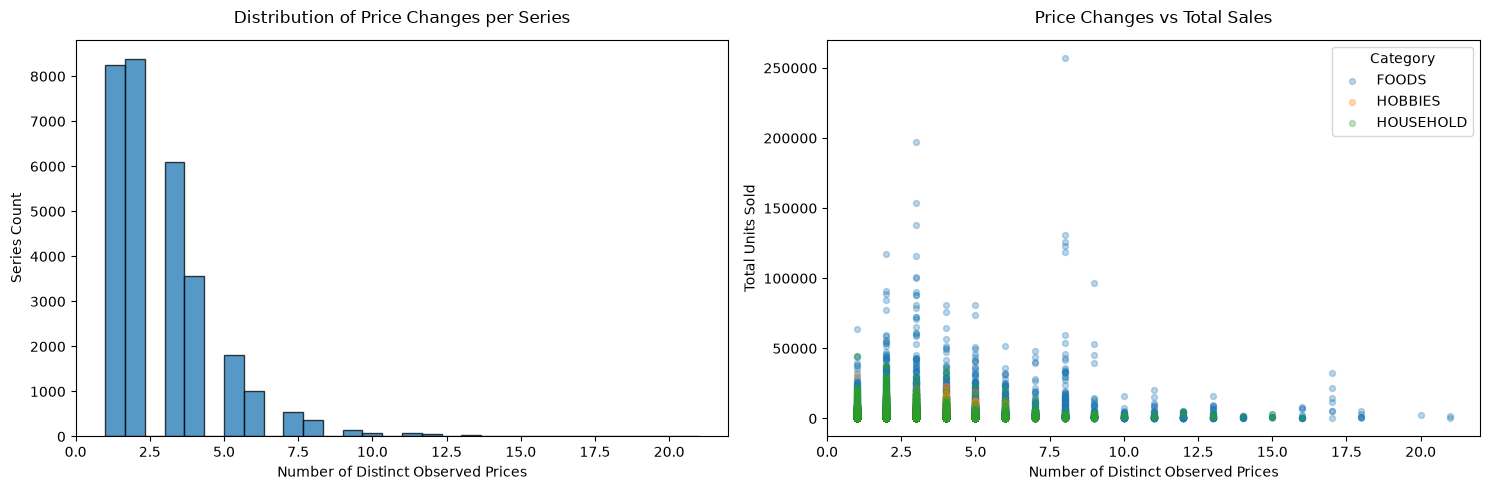

,cat_id,avg_price_changes,median_price_changes,avg_price_range,avg_total_sales
0,HOBBIES,2.331504,2.0,5.706800,1124.951172
1,HOUSEHOLD,2.252818,2.0,5.633048,1437.517090
2,FOODS,3.316562,3.0,3.475105,3253.273193


In [ ]:
price_summary_by_category = (
    price_profile
    .groupby("cat_id", observed=True)
    .agg(
        avg_price_changes=("price_changes", "mean"),
        median_price_changes=("price_changes", "median"),
        avg_price_range=("max_price", "mean"),
        avg_total_sales=("total_sales", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(
    price_profile["price_changes"],
    bins=30,
    color="tab:blue",
    edgecolor="black",
    alpha=0.75,
)
finish_axis(
    axes[0],
    title="Distribution of Price Changes per Series",
    xlabel="Number of Distinct Observed Prices",
    ylabel="Series Count",
)

for cat in sorted(price_profile["cat_id"].unique()):
    data = price_profile.loc[price_profile["cat_id"].eq(cat)]
    axes[1].scatter(
        data["price_changes"],
        data["total_sales"],
        alpha=0.30,
        s=18,
        label=cat,
        color=CATEGORY_COLORS.get(cat, "tab:gray"),
    )

finish_axis(
    axes[1],
    title="Price Changes vs Total Sales",
    xlabel="Number of Distinct Observed Prices",
    ylabel="Total Units Sold",
)
axes[1].legend(title="Category")

plt.show()

price_summary_by_category


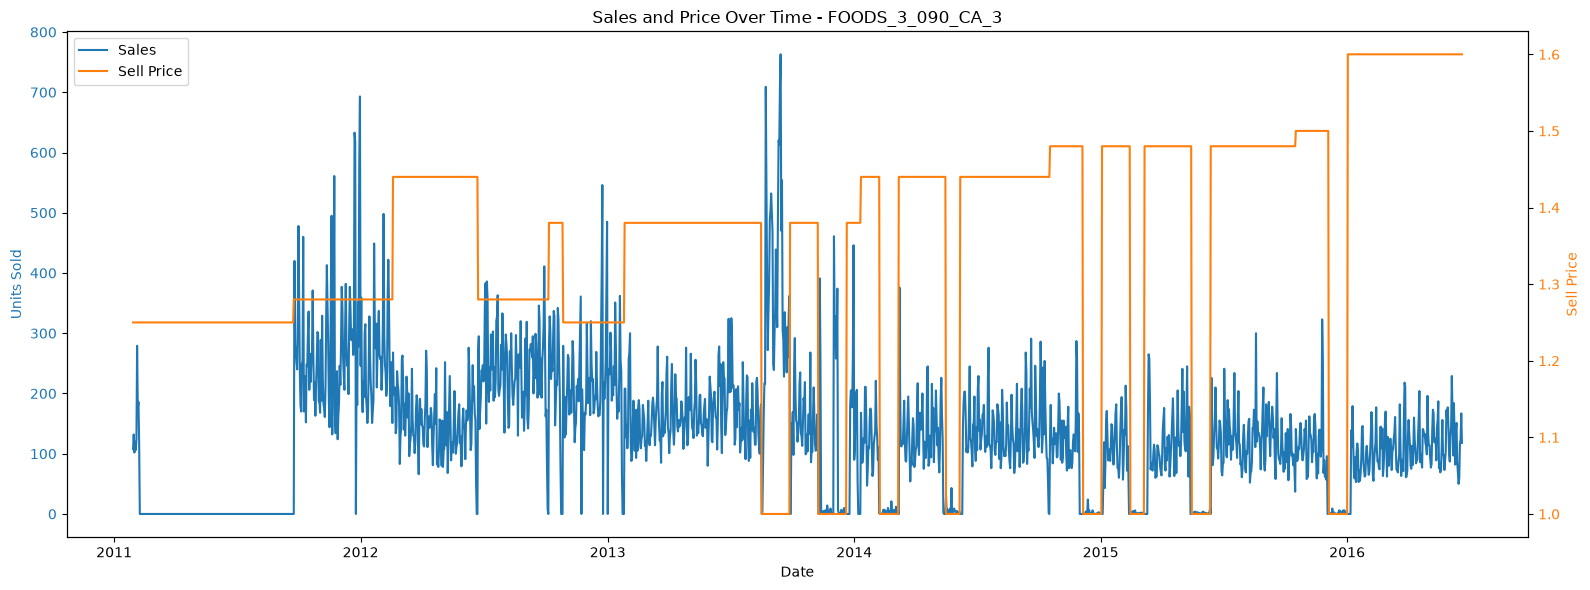

In [ ]:
sample_id = series_profile.sort_values("total_sales", ascending=False)["unique_id"].iloc[0]
sample = m5.loc[m5["unique_id"].eq(sample_id)].copy().sort_values("ds")

fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.plot(sample["ds"], sample["y"], color="tab:blue", label="Sales")
ax1.set_xlabel("Date")
ax1.set_ylabel("Units Sold", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(sample["ds"], sample["sell_price"], color="tab:orange", label="Sell Price")
ax2.set_ylabel("Sell Price", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")
ax1.set_title(f"Sales and Price Over Time - {sample_id}")

plt.tight_layout()
plt.show()


## 15. Save processed analytical tables

These outputs make the next notebooks easier to build because they preserve the main EDA-level aggregates without repeating the joins and groupbys each time.


In [ ]:
category_daily_raw.to_parquet( "data/processedcategory_daily_raw.parquet", index=False)
category_daily_event_enriched.to_parquet(
    "data/processed/category_daily_event_enriched.parquet",
    index=False,
)
category_daily_normalized.to_parquet(
    "data/processed/category_daily_normalized_excluding_christmas.parquet",
    index=False,
)
store_category_daily.to_parquet("data/processed/store_category_daily.parquet", index=False)
state_category_daily.to_parquet("data/processed/state_category_daily.parquet", index=False)
series_profile.to_parquet("data/processed/series_profile.parquet", index=False)

print("Saved processed tables to", "data/processed")


Saved processed tables to data/processed


## 16. Current EDA Conclusions

## Current EDA Conclusions

This first exploration focused on understanding the M5 Walmart sales data before moving into forecasting. The main objective was to understand the sales hierarchy, category-level demand behavior, distribution shape, seasonal patterns, holiday effects, and SKU-store intermittency.

### 1. Overall daily sales show recurring holiday-driven disruptions

The total daily unit sales plot shows a clear time-series structure with recurring drops around December 25. These drops are large enough to visually dominate some charts and can distort distribution analysis and transformation diagnostics.

I decided to keep two versions of the category-level data:

* `category_daily_calendar_enriched`: keeps all dates and includes calendar/event flags.
* `category_daily_normalized`: excludes December 25 only for diagnostic plots.

December 25 is not treated as bad data or deleted from the project. Instead, it is treated as a predictable extreme calendar event. This allows later models to test whether keeping Christmas with event flags performs better than using a normalized training view.

### 2. Category-level sales should be analyzed separately

When all categories are plotted together, `FOODS`, `HOBBIES`, and `HOUSEHOLD` appear to follow broadly similar time-series patterns, including trend, seasonality, and holiday disruptions. However, their sales scales are very different.

Because `FOODS` operates at a much higher volume than `HOBBIES` and `HOUSEHOLD`, combined plots and global summary statistics can be misleading. The global mean and median do not represent any single category well. This supports moving forward with category-level analysis instead of treating total sales as one combined demand series.

### 3. Normalized category views make the underlying patterns easier to inspect

After excluding December 25 from the diagnostic view, the category-level plots become easier to interpret. The extreme Christmas drop no longer dominates the visual scale, making trend and seasonality easier to see.

This does not mean December 25 is irrelevant. It means that for some exploratory views, excluding that recurring extreme event helps reveal the typical demand structure. For forecasting, December 25 should likely remain in the data with event/calendar flags so the model can learn the expected holiday demand suppression.

### 4. Category distributions differ materially

The combined density plot shows that the overall sales distribution is right-skewed and mixed across categories. `HOBBIES` is the most concentrated distribution but has the lowest sales volume. `HOUSEHOLD` sits in the middle, while `FOODS` operates at a much higher scale.

The individual category distribution plots are more informative than the combined distribution. After removing December 25 from the diagnostic view, `FOODS` appears more stable and closer to a symmetric distribution, `HOBBIES` appears relatively concentrated with some outliers, and `HOUSEHOLD` shows more right-skew behavior. These patterns suggest that each category may require different forecasting assumptions and should not be forced into one global model.

### 5. Weekly and monthly seasonality are visible

The day-of-week analysis shows stronger sales on weekends, especially Saturday. This pattern makes business sense because consumers often shop more before or during the weekend.

Monthly patterns also differ by category. `FOODS` tends to show stronger sales around the summer months, while `HOBBIES` and `HOUSEHOLD` show their own seasonal peaks. These seasonal differences suggest that calendar features such as day of week, month, week of year, and holiday indicators should be included in later forecasting models.

### 6. SKU-store demand is more intermittent than category-level demand

Category-level sales appear smoother because they aggregate many item-store series together. At the SKU-store level, demand is much noisier and many series have frequent zero-sales days.

This is especially important for later modeling. Standard time-series methods may work reasonably well at the category level, but SKU-store-level forecasting may require different methods, such as intermittent-demand models or machine learning models with lag, rolling, calendar, and price features.

### 7. Price and economic effects should be explored later, not assumed yet

Some category-level changes appear structural, especially around 2012–2013 for categories like `HOBBIES` and `HOUSEHOLD`. These may be related to broader economic behavior, category assortment changes, pricing, promotions, or other external factors.

At this stage, these are hypotheses rather than conclusions. Later analysis should test whether price changes, calendar events, SNAP indicators, or external macroeconomic variables help explain these shifts. Any claim about price elasticity should be supported with an explicit price-demand analysis.
